# notebook for trying a few ideas

Graph 0: Nodes = 110, Edges = 1210
Graph 1: Nodes = 99, Edges = 1089
Graph 2: Nodes = 78, Edges = 858
Graph 3: Nodes = 73, Edges = 803
Graph 4: Nodes = 88, Edges = 968
Graph 5: Nodes = 74, Edges = 814
Graph 6: Nodes = 100, Edges = 1100
Graph 7: Nodes = 37, Edges = 407
Graph 8: Nodes = 79, Edges = 869
Graph 9: Nodes = 68, Edges = 748
Graph 10: Nodes = 22, Edges = 231
Graph 11: Nodes = 24, Edges = 264
Graph 12: Nodes = 47, Edges = 517
Graph 13: Nodes = 12, Edges = 66
Graph 14: Nodes = 34, Edges = 374
Graph 15: Nodes = 12, Edges = 66
Graph 16: Nodes = 12, Edges = 66
Graph 17: Nodes = 16, Edges = 120
Graph 18: Nodes = 19, Edges = 171
Graph 19: Nodes = 23, Edges = 253
Graph 20: Nodes = 44, Edges = 484
Graph 21: Nodes = 29, Edges = 319
Graph 22: Nodes = 78, Edges = 858
Graph 23: Nodes = 77, Edges = 847
Graph 24: Nodes = 63, Edges = 693
Graph 25: Nodes = 104, Edges = 1144
Graph 26: Nodes = 99, Edges = 1089
Graph 27: Nodes = 110, Edges = 1210
Graph 28: Nodes = 104, Edges = 1144
Graph 29: Nodes

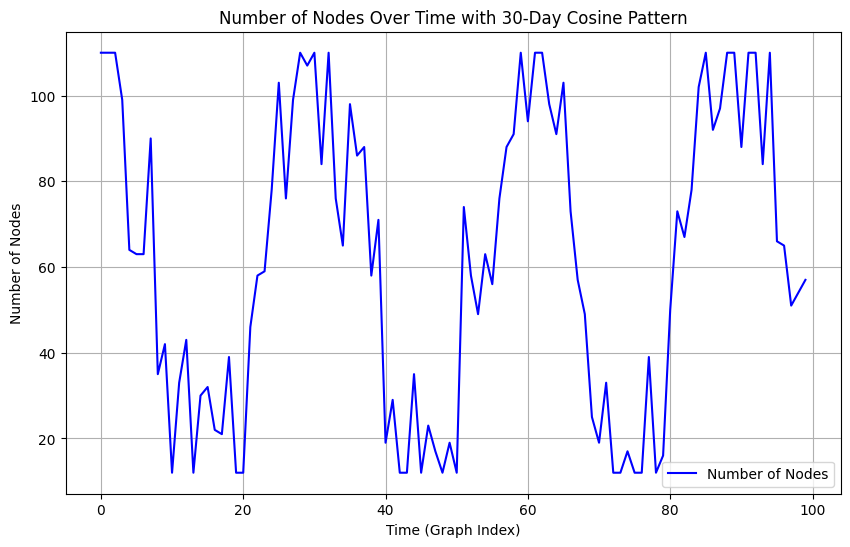

In [45]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

# Function to generate graphs with a cosine cycle pattern for nodes with random edges
def generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size):
    graphs = []
    
    # Cosine pattern with a cycle (adjusted period for nodes)
    node_pattern = (max_nodes / 2) * (1 + np.cos(2 * np.pi * np.arange(num_graphs) / period_days))

    # Create graphs based on the node pattern
    for i in range(num_graphs):
        # Add more randomness to the number of nodes around the cosine pattern to increase variation
        num_nodes = start_size + max(2, min(int(node_pattern[i] + random.uniform(-0.3 * max_nodes, 0.3 * max_nodes)), max_nodes))

        # Create an empty graph with num_nodes
        G = nx.empty_graph(num_nodes)

        # Ensure each node has at least one edge
        for node in G.nodes():
            possible_edges = [edge for edge in nx.non_edges(G) if node in edge]
            if possible_edges:
                selected_edge = random.choice(possible_edges)
                G.add_edge(*selected_edge)
        
        # Randomly add additional edges based on the average number of edges per node
        num_edges = avg_edges_per_node * num_nodes
        possible_edges = list(nx.non_edges(G))
        if num_edges > len(possible_edges):
            num_edges = len(possible_edges)
        selected_edges = np.random.choice(len(possible_edges), int(num_edges), replace=False)
        G.add_edges_from([possible_edges[j] for j in selected_edges])

        # Print the graph details for verification
        print(f"Graph {i}: Nodes = {G.number_of_nodes()}, Edges = {G.number_of_edges()}")
        graphs.append(G)

    return graphs

# Parameters for graph generation
num_graphs = 100 # Number of graphs for training
max_nodes = 100  # Maximum number of nodes
avg_edges_per_node = 10  # Average number of edges per node
period_days = 30  # Set the period of the cosine cycle
start_size = 10  # Starting size for nodes

# Generate graphs with cosine patterns for nodes and random edges
synthetic_graphs = generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size)

# Optional: Plot the number of nodes over time
node_pattern = (max_nodes / 2) * (1 + np.cos(2 * np.pi * np.arange(num_graphs) / period_days))
num_nodes_with_randomness = [
    start_size + max(2, min(int(n + np.random.uniform(-0.3 * max_nodes, 0.3 * max_nodes)), max_nodes))
    for n in node_pattern
]

plt.figure(figsize=(10, 6))
plt.plot(num_nodes_with_randomness, label="Number of Nodes", color="blue")
plt.title(f"Number of Nodes Over Time with {period_days}-Day Cosine Pattern")
plt.xlabel("Time (Graph Index)")
plt.ylabel("Number of Nodes")
plt.grid(True)
plt.legend()
plt.show()


In [46]:
import numpy as np
import networkx as nx
import random
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

# Node activation functions for degree-based filtration
def degree_activation(degrees, threshold):
    return {node for node, degree in degrees.items() if degree <= threshold}

# Compute global degree thresholds based on the degree distribution across all graphs
def compute_degree_thresholds(graphs, num_thresholds=10):
    all_degrees = []
    
    # Collect all degrees from all graphs
    for graph in graphs:
        degrees = dict(graph.degree()).values()
        all_degrees.extend(degrees)
    
    # Compute the thresholds based on quantiles of the degree distribution
    thresholds = np.percentile(all_degrees, np.linspace(0, 100, num_thresholds + 1)[1:])
    
    return thresholds

# Filtration function for generating embeddings (20-dimensional active data)
def graph_filtration(graph, metric, activation_func, thresholds):
    active_data = []
    
    for threshold in thresholds:
        active_node_set = activation_func(metric, threshold)
        active_edges = {edge for edge in graph.edges() if edge[0] in active_node_set and edge[1] in active_node_set}
        # Each filtration gives 2 features: (number of active edges, number of active nodes)
        active_data.extend([len(active_node_set), len(active_edges)])  # 2 features per threshold
    
    return active_data  # 20-dimensional vector

# Process the graphs and generate embeddings (each embedding is 20-dimensional)
def process_graphs_for_embeddings(graphs):
    all_embeddings = []
    
    # Compute global thresholds based on all graphs
    thresholds = compute_degree_thresholds(graphs, num_thresholds=10)
    
    for graph in graphs:
        metric = dict(graph.degree())  # Degree centrality as metric
        active_data = graph_filtration(graph, metric, degree_activation, thresholds)   
        all_embeddings.append(active_data)  # 20-dimensional embedding
    
    return all_embeddings

# Parameters for graph generation (example from your previous code)
num_graphs = 1000  # Adjust the number of graphs for training
max_nodes = 100  # Maximum number of nodes
avg_edges_per_node = 5  # Average number of edges per node
period_days = 30  # Set the period of the cosine cycle
start_size = 10  # Starting size for nodes

# Generate synthetic graphs with cosine patterns for nodes and random edges
# synthetic_graphs = generate_cosine_pattern_graphs(num_graphs, max_nodes, avg_edges_per_node, period_days, start_size)

# Generate embeddings from synthetic graphs using learned thresholds
#embeddings = process_graphs_for_embeddings(synthetic_graphs)

In [47]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.hidden_dim = hidden_dim
        self.Wa = nn.Linear(hidden_dim, hidden_dim)  # Attention weight matrix
        self.Ua = nn.Linear(hidden_dim, hidden_dim)  # Context weight matrix

    def forward(self, x):
        # Compute attention scores
        scores = torch.tanh(self.Wa(x))  # Shape: (batch_size, seq_length, hidden_dim)
        weights = torch.softmax(scores, dim=1)  # Shape: (batch_size, seq_length, hidden_dim)

        # Compute context vector as the weighted sum of the input
        context = torch.bmm(weights.transpose(1, 2), x)  # Shape: (batch_size, hidden_dim, hidden_dim)
        return context, weights

In [ ]:
class LSTMGRUPredictor(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim_1=64, hidden_dim_2=32, num_layers_LSTM=1, num_layers_GRU=1):
        super(LSTMGRUPredictor, self).__init__()
        self.hidden_dim_1 = hidden_dim_1
        self.hidden_dim_2 = hidden_dim_2
        self.hidden_dim_low_scaled = (self.hidden_dim_2//2)
        self.num_layers = num_layers
        
         # Define LSTM layers
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=self.hidden_dim_1, num_layers=num_layers_LSTM)
        self.lstm2 = nn.LSTM(input_size=self.hidden_dim_1, hidden_size=self.hidden_dim_2, num_layers=num_layers_LSTM)
        self.lstm3 = nn.LSTM(input_size=self.hidden_dim_2, hidden_size=self.hidden_dim_low_scaled, num_layers=num_layers_LSTM)

        # Define GRU layers
        self.gru1 = nn.GRU(input_size=self.hidden_dim_low_scaled, hidden_size=self.hidden_dim_low_scaled, num_layers=num_layers_GRU)
        self.gru2 = nn.GRU(input_size=self.hidden_dim_low_scaled, hidden_size=self.hidden_dim_low_scaled, num_layers=num_layers_GRU)
        self.gru3 = nn.GRU(input_size=self.hidden_dim_low_scaled, hidden_size=self.hidden_dim_low_scaled, num_layers=num_layers_GRU)

        #self.attention = Attention(self.hidden_dim_low_scaled)
        #self.dropout = nn.Dropout(p=dropout_prob)

        # Fully connected layers
        self.fc1 = nn.Linear(self.hidden_dim_low_scaled, 100)
        self.fc2 = nn.Linear(100, output_dim)

        # Activation function
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
        # Implement a regularization penalty
    
    def forward(self, x):

        # Forward pass through the LSTM layers
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x, _ = self.lstm3(x)

        # Forward pass through the GRU layers
        x, _ = self.gru1(x)
        x, _ = self.gru2(x)
        x, _ = self.gru3(x)

        #context, _ = self.attention(x)

        # Pass through the fully connected layers
        
        #x = x[:, -1, :]  # Take the output from the last time step
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

In [49]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Assuming 'embeddings' is the full data you are working with
# Split the embeddings into training and test sets (80% train, 20% test)
#train_embeddings, test_embeddings = train_test_split(embeddings, test_size=0.2, shuffle=False)

# Dataset class for embeddings with flexibility for both train and test sets
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = embeddings
    
    def __len__(self):
        return len(self.embeddings) - 1  # We want to predict the next embedding
    
    def __getitem__(self, idx):
        x = torch.Tensor(self.embeddings[idx]).unsqueeze(0)  # Add sequence dimension
        y = torch.Tensor(self.embeddings[idx + 1])  # Next embedding as target
        return x, y
    
class BinaryDataset(Dataset):
    def __init__(self, embeddings, truth):
        self.embeddings = embeddings
        self.truth = truth
    
    def __len__(self):
        return len(self.embeddings)
    
    def __getitem__(self, idx):
        x = torch.FloatTensor(self.embeddings[idx]) 
        y = torch.LongTensor([self.truth.iloc[idx]])
        return x, y


def train_model(model, train_loader, optimizer, num_layers, hidden_dim_1, hidden_dim_2, criterion):
    model.train()
    epoch_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()

        # Reset hidden state for each batch (match batch size of x)
        hidden = ((torch.zeros(num_layers, x.size(0), hidden_dim_1).to(x.device), 
                    torch.zeros(num_layers, x.size(0), hidden_dim_1).to(x.device)),  
                    (torch.zeros(num_layers, x.size(0), hidden_dim_2).to(x.device),  
                    torch.zeros(num_layers, x.size(0), hidden_dim_2).to(x.device)),  
                    (torch.zeros(num_layers, x.size(0), hidden_dim_2).to(x.device), 
                    torch.zeros(num_layers, x.size(0), hidden_dim_2).to(x.device))
        )

        output = model(x)
        y = y.float()

        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(train_loader)
    

In [50]:
def display_graph(graph, time_index):
    print(f'Below are the statistics for the graph at time index: {time_index}')
    print(f'\tThere are {nx.number_of_nodes(graph)} nodes in the graph')
    print(f'\tThere are {nx.number_of_edges(graph)} edges in the graph')
    
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph)  # Use spring layout for better spacing
    nx.draw(graph, pos, with_labels=True)
    plt.title(f"Graph for time index {time_index}")
    plt.show()
    plt.clf()
    

# Compare Embeddings to GraphPulse Results

In [ ]:
import pandas as pd
import os
# Get GraphPulse Data
from my_utils.dataloader import MyDataLoader

my_loader = MyDataLoader()

datasets = ['CollegeMsg', 'networkadex', 'networkaragon', 'networkcoindash', 'mathoverflow']
num_layer = 3
hidden_dims = [64, 128, 256, 512]
dropouts = [0.2, 0.35, 0.5]
hidden_dim_1 = [64, 128, 256, 512]
hidden_dim_2 = [32, 64, 128, 256]
learning_rates = [0.0001, 0.001]
epochs = [500, 750, 1000]

dropout = 0.2

csv_file_path = 'results/BCETesting/graphpulsetesting_3layers.csv'

# Write the header if the file doesn't already exist
if not os.path.isfile(csv_file_path):
    pd.DataFrame(columns=['dataset', 'hidden_dim_1', 'hidden_dim_2', 'learning_rate', 'num_epochs', 'num_layers', 'aucroc', 'loss']).to_csv(csv_file_path, index=False)


# ToDo: Eventually, not immediately, work on having it train on all datasets simultaneously

for dataset in datasets:
    # Prep data
    truth = my_loader.read_labels(dataset)
    truth = truth.iloc[:, 0]
    data = my_loader.load_data(dataset)
    embeddings = process_graphs_for_embeddings(data)
    X_train, X_test, y_train, y_test = train_test_split(embeddings, truth, test_size=0.2, shuffle=False)
    true_graphs = data[(int(len(data) * 0.8)):]  # Select the true graphs to display
    train_dataset = BinaryDataset(X_train, y_train)
    test_dataset = BinaryDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)  
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    
    y_test = y_test.values
    
    #for hidden_dim in hidden_dims:
    #for dropout in dropouts:
    for hidden_1 in hidden_dim_1:
        for hidden_2 in hidden_dim_2:
            for lr_val in learning_rates:
                for epoch_val in epochs:                    
                    dropout_rate = dropout
                    input_dim = 20  # 20-dimensional embeddings
                    output_dim = 1  # Predict the next 20-dimensional embedding
                    num_layers = num_layer
                    learning_rate = lr_val

                    # Define the model (assuming LSTMGRUPredictor is defined elsewhere)
                    model = LSTMGRUPredictor(input_dim, output_dim, hidden_dim_1=hidden_1, hidden_dim_2=hidden_2, num_layers_LSTM=num_layers, num_layers_GRU=num_layers)
                    criterion = nn.BCELoss()
                    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
                    
                    for epoch in range(epoch_val):
                        loss = train_model(model, train_loader, optimizer, num_layers, hidden_1, hidden_2, criterion)
                        if epoch % 5 - 4 == 0:
                            print(f"Epoch {epoch+1}/{epoch_val}, Loss: {loss}")

                    split_index = len(X_train)  # The start of the test set time index
                    
                    model.eval()
                    test_loss = 0
                    time_index = split_index  # Start time index at the beginning of the test set

                    predicted_embeddings = []

                    with torch.no_grad():
                        
                        hidden = None  # Initialize hidden state
                        for (x, y), true_graph in zip(test_loader, true_graphs):
                            output = model(x)  # Maintain hidden state across time steps
                            predicted_embeddings.append(output.numpy())
                            y = y.float()
                            loss = criterion(output, y)
                            test_loss += loss.item()
                            
                            '''
                            # Print time index, predicted embedding, and real embedding
                            for i in range(len(x)):
                                predicted_embedding = output[i].numpy()
                                real_embedding = y[i].numpy()
                                
                                # Visualize 20-dim embeddings
                                print(f"Time Index:\t{time_index}\tPredicted Embedding:\t{'\t'.join(map(str, predicted_embedding))}\tReal Embedding:\t{'\t'.join(map(str, real_embedding))}")
                                display_graph(true_graph, time_index) 
                                
                                # Plot the predicted vs real embeddings
                                pred_edges_data = predicted_embedding[1::2]  # Odd indices
                                pred_nodes_data = predicted_embedding[0::2]  # Even indices
                                true_edges_data = real_embedding[1::2]
                                true_nodes_data = real_embedding[0::2]
                                x_indices = list(range(1, len(predicted_embedding) // 2 + 1))
                                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

                                # Plot edges
                                ax1.plot(x_indices, pred_edges_data, marker='o', color='orange')
                                ax1.plot(x_indices, true_edges_data, marker='o', color='blue')
                                ax1.set_title("Edges")
                                ax1.set_xlabel("Filtration Degree")
                                ax1.set_ylabel("Value")

                                # Plot nodes
                                ax2.plot(x_indices, pred_nodes_data, marker='o', color='orange')
                                ax2.plot(x_indices, true_nodes_data, marker='o', color='blue')
                                ax2.set_title("Nodes")
                                ax2.set_xlabel("Filtration Degree")
                                ax2.set_ylabel("Value")

                                # Display the plots
                                plt.tight_layout()
                                plt.show()
                                plt.clf()
                                
                                print("-" * 50)
                                time_index += 1
                            
                            # Print time index, predicted embedding, and real embedding
                            for i in range(len(x)):
                                predicted_embedding = output[i].numpy()
                                real_embedding = y[i].numpy()                            
                                predicted_embeddings.append(predicted_embedding)  # add to list for reconstruction
                                time_index += 1'''

                    loss = test_loss/len(test_loader)
                    print(f"Test Loss: {loss}")
                    
                    predicted_embeddings = np.concatenate(predicted_embeddings).flatten()  # Flatten if it's a list
                    y_test = y_test.flatten()  # Ensure y_test is a flat array
                    
                    print(y_test)
                    print(predicted_embeddings)
                    print(y_test.shape)
                    print(predicted_embeddings.shape)
                    y_test = np.array(y_test)
                    predicted_embeddings = np.array(predicted_embeddings)
                    auc_roc = my_loader.compute_results(predicted_embeddings, y_test)
                    
                    # Write to dataframe
                    new_row = {
                        'dataset': dataset,
                        'hidden_dim_1': hidden_1,
                        'hidden_dim_2': hidden_2,
                        #'hidden_dim': hidden_dim,
                        'learning_rate': lr_val,
                        #'dropout': dropout,
                        'num_epochs': epoch_val,
                        'num_layers': num_layer,
                        'aucroc': auc_roc, 
                        'loss': loss
                    }

                    pd.DataFrame([new_row]).to_csv(csv_file_path, mode='a', header=False, index=False)
                        
# Generate the floating-point difference between predicted and real values to gain some insight to how much it is overshooting
# Visualize/Display the graph or graph statistics for a given graph timestamp

INFO: Loading a Graph from `Temporal Graph Classification (TGC)` Category: CollegeMsg
INFO: Number of unique snapshots: 177
Epoch 5/500, Loss: 0.6938314769003127
Epoch 10/500, Loss: 0.6902420785692003
Epoch 15/500, Loss: 0.6879335509406196
Epoch 20/500, Loss: 0.6834367778566148
Epoch 25/500, Loss: 0.6868380109469095
Epoch 30/500, Loss: 0.6867579751544528
Epoch 35/500, Loss: 0.6864007181591458
Epoch 40/500, Loss: 0.6847008996539645
Epoch 45/500, Loss: 0.6825770735740662
Epoch 50/500, Loss: 0.6851983798874749
Epoch 55/500, Loss: 0.6831953393088447
Epoch 60/500, Loss: 0.6843087010913425
Epoch 65/500, Loss: 0.6834532419840494
Epoch 70/500, Loss: 0.681825598080953
Epoch 75/500, Loss: 0.6837724248568217
Epoch 80/500, Loss: 0.6820376515388489
Epoch 85/500, Loss: 0.6825633843739828
Epoch 90/500, Loss: 0.6817314624786377
Epoch 95/500, Loss: 0.6804285579257541
Epoch 100/500, Loss: 0.6800485054651896
Epoch 105/500, Loss: 0.6794229944547018
Epoch 110/500, Loss: 0.6794019672605727
Epoch 115/500, Lo

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [ ]:
# Compare results to each other

"predicted_embeddings.insert(0, train_embeddings[-1])  # So that we can get the growth or shrink of the first embedding\nedge_prediction = my_loader.to_labels(predicted_embeddings)\ntruth = my_loader.read_labels('networkadex')\n\n# Modify truth to be usable in rocauc calculation\ntruth = truth['1'].tolist()\ntruth = truth[(int(len(truth) * (0.8)) + 1):]\n\nauc_roc = my_loader.compute_results(edge_prediction, truth)"

# Reconstructing Graph (Three Methods)

In [ ]:
import time
import networkx as nx
import numpy as np
import math
import random

from my_utils.utils import Utils

Code used in all methods    

In [ ]:
# The real graphs to compare to
true_graphs = synthetic_graphs[(int(len(synthetic_graphs) * (0.8)) + 1):]  # Can change based on train/test split size

helper = Utils()

Helper Functions

In [ ]:

def greedy_fill(features):
    """
    Creates a graph such that we fill the graph using a greedy-inspired algorithm

    Args:
        features (list): The provided features for a graph (assuming only node_num and edge_num at each filtration)

    Returns:
        graph (nx.Graph()): The newly created graph
    """
    graph = nx.Graph()
    
    # Base graph features
    num_nodes = 0  # Also works to label nodes for adding edges
    num_edges = 0  
    curr_degree = 1  # Allows quick referencing of node degree
            
    for i in range(0, len(features), 2):
        total_num_nodes = features[i]  # Stores the number of nodes supposed to be in the graph now
        num_nodes_to_add = total_num_nodes - num_nodes
        for j in range(num_nodes_to_add):
            graph.add_node(num_nodes, degree=curr_degree)
            num_nodes += 1
        
        curr_degree += 1  # Increment the degree        
    
    num_edges_to_add = features[-1] - num_edges
    
    while num_edges < num_edges_to_add:
        edges_added = False
    
        unfilled_nodes = [node for node in graph.nodes if graph.degree(node) < graph.nodes[node]['degree']]  # Select all nodes that are not 'complete'
        random.shuffle(unfilled_nodes)
        
        for source in unfilled_nodes:
            if graph.degree(source) >= graph.nodes[source]['degree']:
                continue
            
            for target in unfilled_nodes:
                # Assuming no self loops are allowed
                if source == target:
                    continue
        
                if graph.degree(source) >= graph.nodes[source]['degree'] or graph.degree(target) >= graph.nodes[target]['degree']:
                    continue
        
                # Check if source and target dont have an edge
                if not graph.has_edge(source,target):
                    #print(f'Adding an edge to a node of degree {graph.degree(target)} that needs degree {graph.nodes[target]['degree']}')
                    graph.add_edge(source, target)
                    
                    # Updates
                    edges_added = True
                    num_edges += 1
                    
                    # Halt condition
                    if graph.degree(source) >= graph.nodes[source]['degree']:
                        break
                    
                    # Halt condition
                    if edges_added >= num_edges_to_add:
                        break
                    
                    break
            
            if edges_added:
                break
        
        if not edges_added:
            print('Cant add any more edges')
            break
            
    # Verify the graph was constructed properly
    unfilled_nodes = [node for node in graph.nodes if graph.nodes[node]['degree'] != graph.degree(node)]    
    if(len(unfilled_nodes)) > 0:
        for node in unfilled_nodes:
            print(f'Node #{node} is missing {(graph.nodes[node]['degree'] - graph.degree(node))} edges. Only has {graph.degree(node)} edges')
    
    return graph    

In [ ]:
predicted_embeddings = helper.round_features(predicted_embeddings, num_extra_features=0)
edit_distances = []
similarity_scores = [] 
graph_num = 1

# Create a graph and compare it to the corresponding true graph
for graph_embedding, true_graph in zip(predicted_embeddings, true_graphs):
    curr_graph = greedy_fill(graph_embedding)  # Create graph
    scores, edit_distance = helper.compute_similarity(curr_graph, true_graph)  # Get metrics
    
    # Add scores to the list
    similarity_scores.append(scores)
    edit_distances.append(edit_distance)
    
    graph_num += 1
    
    
# Display how far off we were for each metric as plt
helper.display_edit_differences(edit_distances)

Node #11 is missing 1 edges. Only has 0 edges
Node #243 is missing 3 edges. Only has 2 edges
Node #244 is missing 1 edges. Only has 4 edges
Node #247 is missing 1 edges. Only has 4 edges
Node #254 is missing 2 edges. Only has 3 edges
Node #255 is missing 1 edges. Only has 4 edges
Node #256 is missing 2 edges. Only has 3 edges
Node #258 is missing 2 edges. Only has 3 edges
Node #259 is missing 2 edges. Only has 3 edges
Node #260 is missing 1 edges. Only has 4 edges
Node #264 is missing 1 edges. Only has 4 edges
Node #265 is missing 3 edges. Only has 2 edges
Node #268 is missing 2 edges. Only has 3 edges
Node #269 is missing 4 edges. Only has 1 edges
Node #272 is missing 3 edges. Only has 2 edges
Node #274 is missing 3 edges. Only has 2 edges
Node #275 is missing 2 edges. Only has 3 edges
Node #276 is missing 1 edges. Only has 4 edges
Node #281 is missing 2 edges. Only has 3 edges
Node #282 is missing 1 edges. Only has 4 edges
Node #285 is missing 2 edges. Only has 3 edges
Node #289 is m

TypeError: Utils.display_graph() takes 3 positional arguments but 4 were given

Method 2: Local Search Based on Node Degree Completiton

In [ ]:
def local_assemble(features):
    graph = nx.Graph()

    num_nodes = 0  # Also works to label nodes for adding edges
    num_edges = 0  
    curr_degree = 1  # Allows quick referencing of node degree
            
    for i in range(0, len(features), 2):
        total_num_nodes = features[i]  # Stores the number of nodes supposed to be in the graph now
        num_nodes_to_add = total_num_nodes - num_nodes
        for j in range(num_nodes_to_add):
            graph.add_node(num_nodes, degree=curr_degree)
            num_nodes += 1
        
        curr_degree += 1  # Increment the degree        
    
    # Step 2: Start local search for edge creation
    max_iterations = 1000
    iterations = 0
    improvements = True

    while iterations < max_iterations and improvements:
        improvements = False

        unfilled_nodes = [node for node in graph.nodes if graph.degree(node) < graph.nodes[node]['degree']]
        
        if len(unfilled_nodes) < 2:
            break

        # Randomly select a pair of nodes to attempt to connect
        source = random.choice(unfilled_nodes)
        target = random.choice(unfilled_nodes)

        if source != target and not graph.has_edge(source, target):
            # Check if adding this edge would help meet degree requirements
            if (graph.degree(source) < graph.nodes[source]['degree'] and graph.degree(target) < graph.nodes[target]['degree']):
                graph.add_edge(source, target)
                improvements = True

            # If adding the edge causes any node to exceed its degree, we might need to adjust
            for node in graph.nodes:
                if graph.degree(node) > graph.nodes[node]['degree']:
                    # Remove an edge to balance
                    edges = list(graph.edges(node))
                    if edges:
                        edge_to_remove = random.choice(edges)
                        graph.remove_edge(*edge_to_remove)

        iterations += 1

    # Verify the graph was constructed properly
    unfilled_nodes = [node for node in graph.nodes if graph.nodes[node]['degree'] != graph.degree(node)]    
    if(len(unfilled_nodes)) > 0:
        for node in unfilled_nodes:
            print(f'Node #{node} is missing {(graph.nodes[node]['degree'] - graph.degree(node))} edges. Only has {graph.degree(node)} edges')

    return graph

In [ ]:
def local_assemble_degree(features):
    graph = nx.Graph()

    num_nodes = 0  # Also works to label nodes for adding edges
    num_edges = 0  
    curr_degree = 1  # Allows quick referencing of node degree
    necessary_edges = helper.calculate_necessary_edges(features)
    
    print(f'There should be {necessary_edges} edges in this graph with feature vector {features}')  # Debugging  
    
    # Fill a graph of just nodes (no edges yet)
    for i in range(0, len(features), 2):
        total_num_nodes = features[i]  # Stores the number of nodes supposed to be in the graph now
        num_nodes_to_add = total_num_nodes - num_nodes
        for j in range(num_nodes_to_add):
            graph.add_node(num_nodes, degree=curr_degree)
            num_nodes += 1
        
        curr_degree += 1  # Increment the degree        
    
    max_iterations = 5000
    iterations = 0
    trials_without_improvements = 0
    improvements_limit = 500
    curr_unfilled = num_nodes  # To track our improvements
    no_candidates = False

    while iterations < max_iterations and trials_without_improvements < improvements_limit:
        # Need to add a link to the graph
        if num_edges < necessary_edges and not no_candidates:
            unfilled_nodes = [node for node in graph.nodes if graph.degree(node) < graph.nodes[node]['degree']]
        
            if len(unfilled_nodes) < 2:
                no_candidates = True
                continue

            # Randomly select a pair of nodes to attempt to connect
            source = random.choice(unfilled_nodes)
            target = random.choice(unfilled_nodes)

            if source != target and not graph.has_edge(source, target):
                tmp_graph = graph.copy()
                tmp_graph.add_edge(source, target)
                new_unfilled = helper.count_incomplete(tmp_graph)

                # Need to think of a way to represent there wasnt an improvement but we also didnt worsen (thinking of doing candidates)
                if new_unfilled < curr_unfilled:
                    graph = tmp_graph.copy()
                    trials_without_improvements = 0
                
                else:
                    trials_without_improvements += 1

                num_edges += 1

        # Delete an edge and try it somewhere else
        elif num_edges == necessary_edges or no_candidates:
            # Choose a random edge to delete
            edge = random.choice(list(graph.edges()))
            source, target = edge

            tmp_graph = graph.copy()

            tmp_graph.remove_edge(source, target)
            num_edges -= 1

            # Below is same logic of adding edge normally
            unfilled_nodes = [node for node in graph.nodes if graph.degree(node) < graph.nodes[node]['degree']]
        
            if len(unfilled_nodes) < 2:
                no_candidates = False 
                num_edges -= 1
                continue

            # Randomly select a new pair of nodes to attempt to connect
            source = random.choice(unfilled_nodes)
            target = random.choice(unfilled_nodes)

            if source != target and not graph.has_edge(source, target):
                tmp_graph.add_edge(source, target)
                new_unfilled = helper.count_incomplete(tmp_graph)

                # Need to think of a way to represent there wasnt an improvement but we also didnt worsen (thinking of doing candidates)
                if new_unfilled < curr_unfilled:
                    graph = tmp_graph.copy()
                    trials_without_improvements = 0
                
                else:
                    trials_without_improvements += 1

                num_edges += 1


        # Debugging, we should never have this occur
        elif num_edges > necessary_edges:
            print('TOO MANY EDGES')

        iterations += 1

    # Verify the graph was constructed properly
    unfilled_nodes = [node for node in graph.nodes if graph.nodes[node]['degree'] != graph.degree(node)]    
    if(len(unfilled_nodes)) > 0:
        for node in unfilled_nodes:
            print(f'Node #{node} is missing {(graph.nodes[node]['degree'] - graph.degree(node))} edges. Only has {graph.degree(node)} edges')

    return graph

In [ ]:
edit_distances = []
similarity_scores = [] 

# Create a graph and compare it to the corresponding true graph
for graph_embedding, true_graph in zip(predicted_embeddings, true_graphs):
    curr_graph = local_assemble_degree(graph_embedding)  # Create graph
    scores, edit_distance = helper.compute_similarity(curr_graph, true_graph)  # Get metrics
    
    # Add scores to the list
    similarity_scores.append(scores)
    edit_distances.append(edit_distance)
    
    
# Display how far off we were for each metric as plt
helper.display_edit_differences(edit_distances)
helper.display_similarity_values(similarity_scores)

Method 3: Local Search Based on Degree (Genetics)

In [ ]:
def local_assemble_genetics(features, num_candidates):
    graph = nx.Graph()



    return graph

# Self Notes

- Compare Embeddings to GraphPulse Growth/Shrink metric
- Implement Linear Regression on the embeddings
- Allow for multiedges
- Look at the concept of rewiring, call my greedy wiring
- Try the step 1 one again but try to impute the average/max or smth when we don't have monotonic behavior
- I need to make a probability function to determine what nodes will receive the next edge
- Include assertivity in the LSTMGRU Embedding for prediction
- Look at GAEs, they create a graph embedding and try to reconstruct the graph from the embedding, I need to look at how they reconstruct the graph
- They probably use some learnable parameters